# Video Action Recognition with Transformers

In [1]:
import os
import math
import numpy as np
import pandas as pd
import cv2
import imageio
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import models, transforms
from IPython.display import Video, Image, display
from tqdm import tqdm

## **Define hyperparameters**

In [2]:
MAX_SEQ_LENGTH = 20
NUM_FEATURES = 1024
IMG_SIZE = 128
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"


## **Data Preprocessing**


### Data collection

we will be using a subsampled version of the [UCF101](https://www.crcv.ucf.edu/data/UCF101.php) dataset, a well-known benchmark dataset used in computer vision and video understanding research, especially for _human action recognition_.
It contains 13,320 short video clips divided into 101 action categories, such as sports, musical activities, and daily human actions, collected from YouTube.

In [ ]:
!wget https://github.com/sayakpaul/Action-Recognition-in-TensorFlow/releases/download/v1.0.0/ucf101_top5.tar.gz
!tar -xvf ucf101_top5.tar.gz

In [ ]:
# display few lines from training dataset
...

### Data preparation

Lets implement first some utility functions

In [5]:
def crop_center(frame: np.ndarray, size: int = IMG_SIZE) -> np.ndarray:
    """Centre-crop a single HWC frame to (size × size)."""
    h, w = frame.shape[:2]
    top  = (h - size) // 2
    left = (w - size) // 2
    return frame[top:top + size, left:left + size]


def load_video(path: str, max_frames: int = 0, center_cropping : bool = True) -> np.ndarray:
    """Read a video file and return an array of shape (T, H, W, 3) uint8."""
    cap = cv2.VideoCapture(path)
    frames = []
    try:
        while True:
            ret, frame = cap.read()
            # print(ret, frame)
            if not ret:
                break
            frame = frame[:, :, ::-1].copy()   # BGR → RGB
            if center_cropping:
                frame = crop_center(frame)
            frames.append(frame)
            if max_frames and len(frames) == max_frames:
                break
    finally:
        cap.release()
    return np.array(frames, dtype=np.uint8)


def to_gif(images: np.ndarray, path: str = "animation.gif", fps: int = 10):
    imageio.mimsave(path, images.astype(np.uint8), fps=fps)
    print(f"Saved animation to {path}")

In [ ]:
# TODO: load train and testing sets into a Pandas Dataframe
train_df = ...
test_df = ...

display(train_df)
print(f"Total videos for training: {len(train_df)}")

display(test_df)
print(f"Total videos for testing: {len(test_df)}")

In [ ]:
_video_path = os.path.join("train", train_df["video_name"][0])
# TODO: run the load_video function with and without the center_cropping
_original_frames = ...
_processed_frames = ...

print("SHAPE: ", _processed_frames.shape)
print("LABEL: ", train_df["tag"][0])

to_gif(_original_frames, path="original.gif")
to_gif(_processed_frames, path="processed.gif")

print("\nOriginal")
display(Image(filename="original.gif"))

print("Processed")
display(Image(filename="processed.gif"))

### Feature extraction

Create the feature extractor using a pre-trained DenseNet121 network

**DenseNet121** is a Convolutional Neural Network (CNN) architecture introduced by Google in 2017 (Huang et al.). It is distinguished by its **dense connectivity**
design, where every layer in a dense block is connected to every subsequent layer in the same block.

**Key Characteristics:**
*   **Feature Reuse:** Every layer has access to all feature maps from all preceding layers, allowing for maximum information flow and feature reuse.
*   **Efficiency:** By reusing features, the model requires fewer learnable parameters and reduces the vanishing gradient problem common in very deep networks.
*   **Structure:** Despite having only 121 layers, it often achieves state-of-the-art accuracy with significantly fewer computational resources compared to standard
ResNet architectures.
*   **Application:** It is widely used in image classification and computer vision tasks due to its strong regularization effect and compactness.


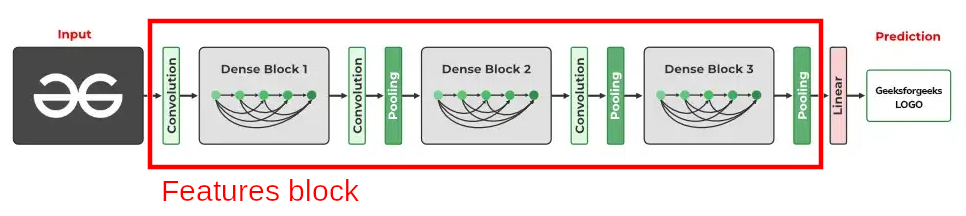

In [ ]:
def build_feature_extractor() -> nn.Module:
    """DenseNet121 up to the global-average-pooling head, output dim = 1024."""
    backbone = models.densenet121(weights=models.DenseNet121_Weights.IMAGENET1K_V1)
    # Remove the classifier; keep everything up to (and including) the adaptive pool
    feature_extractor = nn.Sequential(
        # TODO: get the features block from DenseNet
        ...,
        # NOTE: we are saving space 🎉
        # Since the input tensor is not needed elsewhere in the network (we only pass it sequentially to the next layer),
        # in-place operations save memory because it does not create a new tensor!
        nn.ReLU(inplace=True),
        # NOTE:
        # AdaptiveAvgPool2d is a pooling layer that performs average pooling, but with a twist: instead of specifying the kernel size or stride (like regular pooling),
        # you specify the output size you want, and PyTorch automatically calculates the appropriate kernel size and stride to achieve it.
        nn.AdaptiveAvgPool2d((1, 1)),
        nn.Flatten(),
    )
    feature_extractor.eval()
    return feature_extractor.to(DEVICE)


In [ ]:
_DENSENET_MEAN = [0.485, 0.456, 0.406]
_DENSENET_STD  = [0.229, 0.224, 0.225]

_preprocess = transforms.Compose([
    # TODO: normalization & standardization
    ...,
])

In [ ]:
# test the image processor pipeline
_preprocess(_processed_frames[0]).shape

In [ ]:
@torch.no_grad()
def extract_features(
    feature_extractor: nn.Module,
    frames: np.ndarray,          # (T, H, W, 3)
) -> np.ndarray:                 # (MAX_SEQ_LENGTH, NUM_FEATURES)
    """Run DenseNet121 on up to MAX_SEQ_LENGTH frames; zero-pad shorter clips."""
    result = np.zeros((MAX_SEQ_LENGTH, NUM_FEATURES), dtype=np.float32)
    length = min(len(frames), MAX_SEQ_LENGTH)
    for j in range(length):
        frame = frames[j]
        # NOTE: why mean > 0 ?
        # - True  → the frame has some non-zero pixel values.
        # - False → the frame is completely black (all pixels are zero).
        # So the advantages of this check are:
        # - avoids processing empty or black frames
        # - avoids computational waste
        # - prevent network issues
        if frame.mean() > 0.0:
            # TODO: prepare input for feature extractor
            tensor = ...
            feat = feature_extractor(tensor)            # (1, 1024)
            result[j] = feat.cpu().numpy().squeeze()
    return result

In [ ]:
feature_extractor = build_feature_extractor()
_features = extract_features(feature_extractor, _processed_frames)

print(_features.shape)

In [ ]:
# print input transformation after feature_extractor using just one frame
_x = _preprocess(_processed_frames[0]).unsqueeze(0).to(DEVICE)
print(_x.shape)
# Iterate manually through each layer
for i, layer in enumerate(feature_extractor):
    _x = layer(_x)
    print(f"After layer {i} ({layer.__class__.__name__}): {_x.shape}")

In [14]:
def prepare_all_videos(
    df: pd.DataFrame,
    root_dir: str,
    label_to_idx: dict,
    feature_extractor: nn.Module,
) -> tuple:
    """Extract features for every video in *df*; returns (features, labels)."""
    n = len(df)
    features = np.zeros((n, MAX_SEQ_LENGTH, NUM_FEATURES), dtype=np.float32)
    labels   = np.zeros(n, dtype=np.int64)

    for idx, row in df.iterrows():
        frames = load_video(os.path.join(root_dir, row["video_name"]))
        features[idx] = extract_features(feature_extractor, frames)
        labels[idx]   = label_to_idx[row["tag"]]
        if idx % 50 == 0:
            print(f"  processed {idx}/{n}")

    return features, labels

In [ ]:
# TODO: get unique classes
class_vocab = ...
label_to_idx = {lbl: i for i, lbl in enumerate(class_vocab)}
num_classes = len(class_vocab)
feature_extraction_model = build_feature_extractor()

print(class_vocab)
print(num_classes)

# TODO: use the `prepare_all_videos` function
train_data, train_labels = ...

Calling `prepare_all_videos()` on `train_df` and `test_df` takes ~20 minutes to complete. For this reason, to save time, here we download already preprocessed NumPy arrays:

In [ ]:
!wget https://git.io/JZmf4 -O top5_data_prepared.tar.gz
!tar -xvf top5_data_prepared.tar.gz

In [ ]:
# TODO: load train and testing data
train_data, train_labels = ...
test_data, test_labels = ...

print(f"Frame features in train set: {train_data.shape}")

In [ ]:
class VideoFeatureDataset(Dataset):
    def __init__(self, features: np.ndarray, labels: np.ndarray):
        self.features = torch.from_numpy(features)   # (N, F)
        self.labels   = torch.from_numpy(labels)     # (N,)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        # NOTE: labels are squeezed because we want the DataLoader
        # output shape be like (BS,) not (BS, 1)!!
        return self.features[idx], self.labels[idx].squeeze()

In [ ]:
fulltrain_dataset = VideoFeatureDataset(train_data, train_labels)
val_size     = int(0.15 * len(fulltrain_dataset))
train_size   = len(fulltrain_dataset) - val_size
train_ds, val_ds = random_split(fulltrain_dataset, [train_size, val_size])
test_ds = VideoFeatureDataset(test_data, test_labels)

print("TRAIN DS:", len(train_ds))
print("VAL   DS:", len(val_ds))
print("TEST  DS:", len(test_ds))

In [ ]:
_vid, _lbl = train_ds[0]
print(_vid.shape)
print(_lbl.shape)
print(_lbl)

## **Building the Transformer-based model**

Lets build our classifier model using Transformers architecture.
First of all lets implement the PositionalEmbedding module!

In previous lectures we used the Positional Encoding method, now we are implementing the Positional Embedding layer. Some details below


#### Approach A: Embedding + PositionalEncoding (NLP Style / Additive)
In traditional NLP (like BERT or standard Transformers), tokens are discrete words (IDs).
*   **Embedding:** A lookup table (like `nn.Embedding`) maps discrete token IDs to vectors. This encodes **what** the content is (e.g., the word "run" vs "walk").
*   **PositionalEncoding:** A fixed sinusoidal pattern added to the embedding to encode **where** the token is in the sequence.
*   **Usage:** You typically sum them: `x = token_embedding(x) + pos_encoding`.

#### Approach B: Using `PositionalEmbedding` (Vision Transformer Style / Integrated)
In Vision Transformers (ViT) and Video Action Recognition, inputs are usually image patches or frames (continuous tensors), not discrete text tokens.
*   **PositionalEmbedding:** A dedicated layer that directly initializes learnable positional vectors.
*   With PositionalEmbedding the model treats **location and identity as integrated learnable parameters**, allowing it to flexibly adapt to **temporal sequences** (frames).

#### Why This Matters for Video Action Recognition (UCF101)

UCF101 consists of **video sequences**, which introduces a **temporal dimension**.

1.  **Adaptability to Motion:** By using `PositionalEmbedding` as a learnable layer, the model can learn **spatial-temporal correlations** (e.g., the arm moves
*after* the leg moves). This is crucial for distinguishing actions like "throw" vs. "catch."
2.  **Contextual Learning:** Separating them (`Embedding` + `PosEnc`) assumes the model can learn token identity and position independently. In video, these are
coupled (e.g., the arm's position changes to indicate a "swing"). A unified `PositionalEmbedding` layer helps the model learn this coupling directly.
3. By using `PositionalEmbedding` instead of `Embedding`+`PositionalEncoding` (or a fixed version), you are enabling the model to **learn the spatial-temporal layout of human actions**, which is essential for high-accuracy action recognition in video data.


In [ ]:
class PositionalEmbedding(nn.Module):
    """Learned positional embedding added to frame features."""

    def __init__(self, sequence_length: int, output_dim: int):
        super().__init__()
        self.embedding = nn.Embedding(sequence_length, output_dim)
        self.sequence_length = sequence_length

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: (B, T, F)
        positions = torch.arange(x.size(1), device=x.device)    # (T,)
        pos_emb   = self.embedding(positions)                   # (T, F)
        return x + pos_emb.unsqueeze(0)                         # (B, T, F)

# NOTE:
# this is the Transformers implementation seen during theoretical lectures.
# We are going to use the Pytorch implementation since it is ready to use and reflects a more
# practical approach. Fell free to de-comment this and hack with it!
# class TransformerEncoder(nn.Module):
#     """Single Transformer encoder block with pre-norm (matches Keras LayerNorm placement)."""

#     def __init__(self, embed_dim: int, dense_dim: int, num_heads: int, dropout: float = 0.3):
#         super().__init__()
#         self.attention  = nn.MultiheadAttention(
#             embed_dim, num_heads, dropout=dropout, batch_first=True
#         )
#         self.ffn = nn.Sequential(
#             nn.Linear(embed_dim, dense_dim),
#             nn.GELU(),
#             nn.Linear(dense_dim, embed_dim),
#         )
#         self.norm1 = nn.LayerNorm(embed_dim)
#         self.norm2 = nn.LayerNorm(embed_dim)

#     def forward(self, x: torch.Tensor) -> torch.Tensor:
#         # Self-attention + residual
#         attn_out, _ = self.attention(x, x, x)
#         x = self.norm1(x + attn_out)
#         # Feed-forward + residual
#         ffn_out = self.ffn(x)
#         return self.norm2(x + ffn_out)


class VideoTransformerClassifier(nn.Module):
    def __init__(
        self,
        num_classes:     int,
        sequence_length: int = MAX_SEQ_LENGTH,
        embed_dim:       int = NUM_FEATURES,
        dense_dim:       int = 4,
        num_heads:       int = 1,
        dropout:         float = 0.5,
    ):
        super().__init__()
        # TODO: create the positional embedding
        self.pos_embed   = ...
        # NOTE:
        # if you want to use the manually implemented encoder, de-comment the following line
        # and comment the next one
        # self.transformer = TransformerEncoder(embed_dim, dense_dim, num_heads)
        # TODO: instantiate the TransformerEncoderLayer
        self.transformer = nn.TransformerEncoderLayer(
            d_model=...,
            nhead=...,
            dim_feedforward=...,
            batch_first=True,
            )
        self.pool        = nn.AdaptiveMaxPool1d(1)   # global max over time
        self.dropout     = nn.Dropout(dropout)
        self.classifier  = nn.Linear(embed_dim, num_classes)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: (B, T, F)
        # TODO: write the forward pass
        x = ...                       # (B, T, EMB_DIMS)
        x = ...                       # (B, T, EMB_DIMS)
        x = ...                       # (B, EMB_DIMS, T)
        x = ...                       # (B, EMB_DIMS, 1)
        x = ...                       # (B, EMB_DIMS)
        x = ...                       # (B, F)
        x = ...                       # (B, num_classes)

        return x

In [ ]:
model = VideoTransformerClassifier(num_classes=num_classes).to(DEVICE)

# test the model with just random tensor
print(model(torch.rand(10,20,1024).to(DEVICE)).shape)

In [23]:
EPOCHS = 50
BATCH_SIZE = 32
LEARNING_RATE = 1e-3

### Training

In [24]:
@torch.no_grad()
def evaluate(model, loader, criterion, desc="Evaluate"):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    for features, labels in tqdm(loader, desc=desc):
        features, labels = features.to(DEVICE), labels.to(DEVICE)
        logits = model(features)
        loss   = criterion(logits, labels)

        total_loss += loss.item() * len(labels)
        correct    += (logits.argmax(1) == labels).sum().item()
        total      += len(labels)
    return total_loss / total, correct / total

In [ ]:
# define dataloaders
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE)
test_loader  = DataLoader(test_ds, batch_size=BATCH_SIZE)

optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
criterion = nn.CrossEntropyLoss()

best_val_loss = float("inf")
checkpoint    = "./video_classifier.pt"
history = {
    "loss": {
        "train": [],
        "valid": [],
        },
    "acc": {
        "train": [],
        "valid": [],
    },
}

# train the model
for epoch in range(1, EPOCHS + 1):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for features, labels in tqdm(train_loader, desc=f"Epoch {epoch}"):
        features, labels = features.to(DEVICE), labels.to(DEVICE)

        optimizer.zero_grad()

        logits = model(features)
        loss   = criterion(logits, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item() * len(labels)
        correct    += (logits.argmax(1) == labels).sum().item()
        total      += len(labels)
    
    total_loss /= total
    correct /= total

    va_loss, va_acc = evaluate(model, val_loader, criterion, desc="Validation")
    print(
        f"Epoch {epoch}/{EPOCHS}  "
        f"train_loss={total_loss:.4f}  train_acc={correct:.4f}  "
        f"val_loss={va_loss:.4f}  val_acc={va_acc:.4f}"
    )

    # populate the history dict
    history["loss"]["train"].append(total_loss)
    history["loss"]["valid"].append(va_loss)
    history["acc"]["train"].append(correct)
    history["acc"]["valid"].append(va_acc)

    if va_loss < best_val_loss:
        best_val_loss = va_loss
        torch.save(model.state_dict(), checkpoint)
        print("  → saved best weights")

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(9,5))

axs[0].set_title("Loss")
axs[0].plot(history["loss"]["train"])
axs[0].plot(history["loss"]["valid"])
axs[0].set_xlabel("Epochs")
axs[0].set_ylabel("CrossEntropyLoss value")
axs[0].legend(["Train", "Valid"])

axs[1].set_title("Accuracy")
axs[1].plot(history["acc"]["train"])
axs[1].plot(history["acc"]["valid"])
axs[1].set_xlabel("Epochs")
axs[1].set_ylabel("Accuracy value")
axs[1].legend(["Train", "Valid"])

plt.suptitle("Training Phase")
plt.tight_layout()
plt.show()

### Evaluation

In [ ]:
# evaluate the model
model.load_state_dict(torch.load(checkpoint, map_location=DEVICE))
te_loss, te_acc = evaluate(model, test_loader, criterion)
print(f"\nTest accuracy: {te_acc * 100:.2f}%")

### Get model predictions

In [28]:
@torch.no_grad()
def predict_action(
    path: str,
    trained_model: nn.Module,
    feature_extractor: nn.Module,
    class_vocab: list,
):
    frames         = load_video(os.path.join("test", path))
    frame_features = torch.from_numpy(extract_features(feature_extractor, frames)).unsqueeze(0).to(DEVICE)
    logits         = trained_model(frame_features)[0]            # (num_classes,)
    probs          = F.softmax(logits, dim=-1).cpu().numpy()

    sorted_idx = np.argsort(probs)[::-1]
    plot_labels = [class_vocab[i] for i in sorted_idx]
    plot_probs  = [probs[i] for i in sorted_idx]

    for lbl, p in zip(plot_labels, plot_probs):
        print(f"  {lbl}: {p * 100:5.2f}%")

    plt.bar(plot_labels, plot_probs)
    plt.xlabel("class_label")
    plt.ylabel("Probability")
    plt.tight_layout()
    plt.show()

    return frames


In [ ]:
test_row = test_df.sample(n=1)
test_video = test_row["video_name"].values[0]
test_label = test_row["tag"].values[0]
print(f"Test video path: {test_video}")

test_frames = predict_action(test_video, model, feature_extractor, class_vocab)
to_gif(test_frames[:MAX_SEQ_LENGTH], "testvideo.gif")
display(Image("testvideo.gif"))
print("LABEL:", test_label)